# 03 - Modelado ARIMA para Pronóstico Financiero

En este cuaderno se implementa un modelo ARIMA (AutoRegressive Integrated Moving Average) para pronosticar la variable `target` del dataset financiero. Se utilizarán los retardos (lags) de los activos como características para el modelo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

## 1. Carga de Datos y Preparación

In [2]:
csv_path = Path("..") / "data" / "financial_timeseries_dataset.csv"
df = pd.read_csv(csv_path)

print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (3741, 151)


,AAPL_t-0,GOOGL_t-0,MSFT_t-0,AMZN_t-0,JPM_t-0,AAPL_t-1,GOOGL_t-1,MSFT_t-1,AMZN_t-1,JPM_t-1,...,GOOGL_t-28,MSFT_t-28,AMZN_t-28,JPM_t-28,AAPL_t-29,GOOGL_t-29,MSFT_t-29,AMZN_t-29,JPM_t-29,target
0,0.043028,0.240899,-0.295660,1.065966,-0.027733,-0.968555,-0.933868,-1.525425,0.281621,-0.429868,...,-0.918262,0.848036,1.590391,1.168241,-0.293847,-0.552375,-0.372034,-0.074786,0.475469,0
1,-0.968555,-0.933868,-1.525425,0.281621,-0.429868,-0.160780,-0.879317,-1.410288,1.090576,-0.696672,...,-0.552375,-0.372034,-0.074786,0.475469,0.051374,0.689175,0.500887,0.494442,0.771765,0
2,-0.160780,-0.879317,-1.410288,1.090576,-0.696672,0.322046,1.253776,0.732499,-0.172685,0.378839,...,0.689175,0.500887,0.494442,0.771765,-0.410113,-0.276197,-0.302963,-0.572609,-0.477763,0
3,0.322046,1.253776,0.732499,-0.172685,0.378839,-0.560009,-1.228156,-0.126754,-0.224358,-0.842366,...,-0.276197,-0.302963,-0.572609,-0.477763,-0.409464,0.157195,0.180598,1.128484,-0.134140,1
4,-0.560009,-1.228156,-0.126754,-0.224358,-0.842366,-0.706915,-1.162136,-1.077635,-1.384328,-0.459242,...,0.157195,0.180598,1.128484,-0.134140,-1.018243,-0.363337,-0.873900,-1.407218,-0.918039,1


### Definición de Features y Target

El `target` es la variable a predecir. Las demás columnas (los retardos) serán las features.

In [3]:
target_col = 'target'
features_cols = [col for col in df.columns if col != target_col]

X = df[features_cols]
y = df[target_col]

print(f"Número de features: {len(features_cols)}")
print(f"Primeras 5 filas del target:\n{y.head()}")

Número de features: 150
Primeras 5 filas del target:
0    0
1    0
2    0
3    1
4    1
Name: target, dtype: int64


## 2. División Train/Test

Se divide el dataset en conjuntos de entrenamiento y prueba, manteniendo el orden temporal.

In [4]:
split_ratio = 0.8
split_idx = int(len(df) * split_ratio)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Tamaño del conjunto de entrenamiento: {len(y_train)} muestras")
print(f"Tamaño del conjunto de prueba: {len(y_test)} muestras")

Tamaño del conjunto de entrenamiento: 2992 muestras
Tamaño del conjunto de prueba: 749 muestras


## 3. Modelado ARIMA

Se entrena un modelo ARIMA sobre la serie `target`. Para simplificar, se usará un orden (p,d,q) básico. En un análisis real, este orden se determinaría mediante ACF/PACF o auto_arima.

In [5]:
# Para ARIMA, necesitamos una serie univariante. Usaremos el target directamente.
# Si quisiéramos usar las features, necesitaríamos un modelo VARIMA o similar.
model = ARIMA(y_train, order=(5, 1, 0)) # Ejemplo de orden (p,d,q)
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 target   No. Observations:                 2992
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2381.634
Date:                Sun, 01 Mar 2026   AIC                           4775.268
Time:                        20:48:57   BIC                           4811.288
Sample:                             0   HQIC                          4788.226
                               - 2992                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8446      0.018    -45.673      0.000      -0.881      -0.808
ar.L2         -0.6783      0.023    -29.126      0.000      -0.724      -0.633
ar.L3         -0.5391      0.025    -21.995      0.0

## 4. Pronóstico y Evaluación

Se realiza el pronóstico sobre el conjunto de prueba y se evalúa el rendimiento del modelo.

In [6]:
forecast = model_fit.forecast(steps=len(y_test))
forecast.index = y_test.index

mae = mean_absolute_error(y_test, forecast)
rmse = np.sqrt(mean_squared_error(y_test, forecast))

print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")

MAE (Mean Absolute Error): 0.5172
RMSE (Root Mean Squared Error): 0.5800


### Visualización del Pronóstico

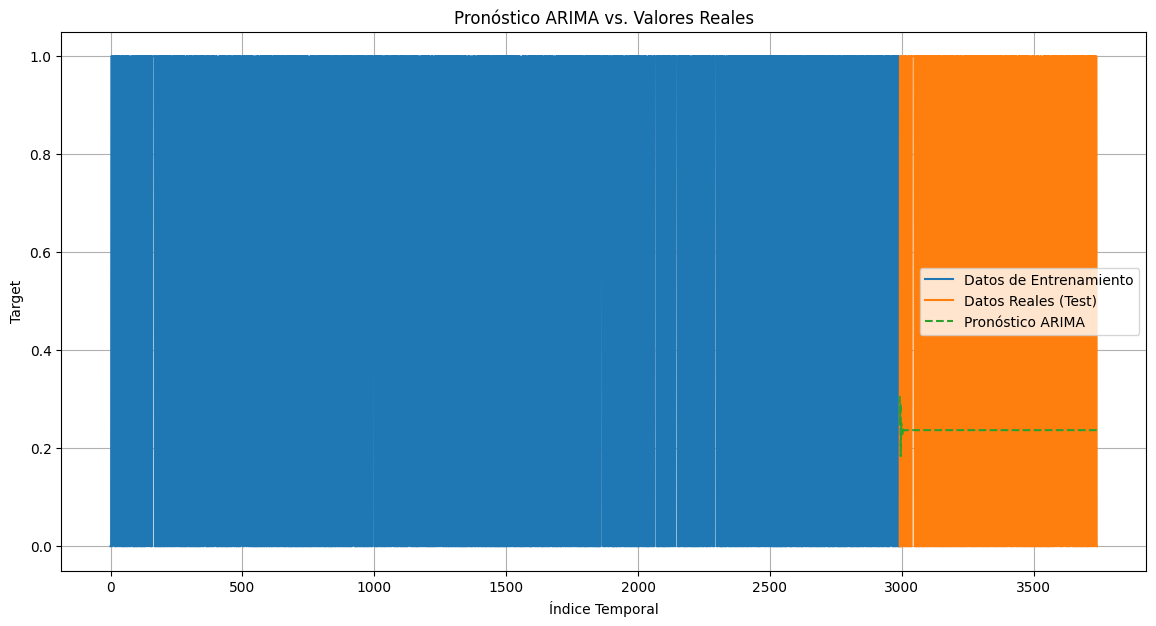

In [7]:
plt.figure(figsize=(14, 7))
plt.plot(y_train.index, y_train, label='Datos de Entrenamiento')
plt.plot(y_test.index, y_test, label='Datos Reales (Test)')
plt.plot(forecast.index, forecast, label='Pronóstico ARIMA', linestyle='--')
plt.title('Pronóstico ARIMA vs. Valores Reales')
plt.xlabel('Índice Temporal')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.show()

## 5. Conclusiones

- El modelo ARIMA proporciona un pronóstico inicial para la serie `target`.
- La elección del orden (p,d,q) es crucial y puede optimizarse.
- Para un análisis más completo, se podrían explorar modelos multivariantes (VARIMA) que incorporen directamente los retardos de todas las acciones como features, o modelos más avanzados como Prophet o redes neuronales (LSTM).